In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
# Summary statistics
data_summary = {
    'Segment': ['Organic-End Customer', 'Contractor-Influenced'],
    'Mean': [2794.777778, 4655.555556],
    'Std': [1972.866999, 2541.215807],
    'Min': [1273, 1850],
    'Max': [7200, 9500]
}
df_summary = pd.DataFrame(data_summary)

# Simulate data based on normal distribution, clipped to min/max
np.random.seed(42)
n_samples = 9  # Based on SUM ÷ AVERAGE ≈ 9 transactions per segment
simulated_data = {}
for index, row in df_summary.iterrows():
    segment = row['Segment']
    mean = row['Mean']
    std = row['Std']
    min_val = row['Min']
    max_val = row['Max']
    simulated_data[segment] = np.random.normal(mean, std, n_samples).clip(min_val, max_val)

# Create DataFrame
df = pd.DataFrame(simulated_data)
print(df.head())

   Organic-End Customer  Contractor-Influenced
0           3774.728738            6034.317715
1           2522.000701            3477.911190
2           4072.581120            3472.035744
3           5799.513120            5270.433905
4           2332.824312            1850.000000


/tmp/ipython-input-4-1336455387.py:21: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[column], label=column, shade=True)
/tmp/ipython-input-4-1336455387.py:21: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[column], label=column, shade=True)


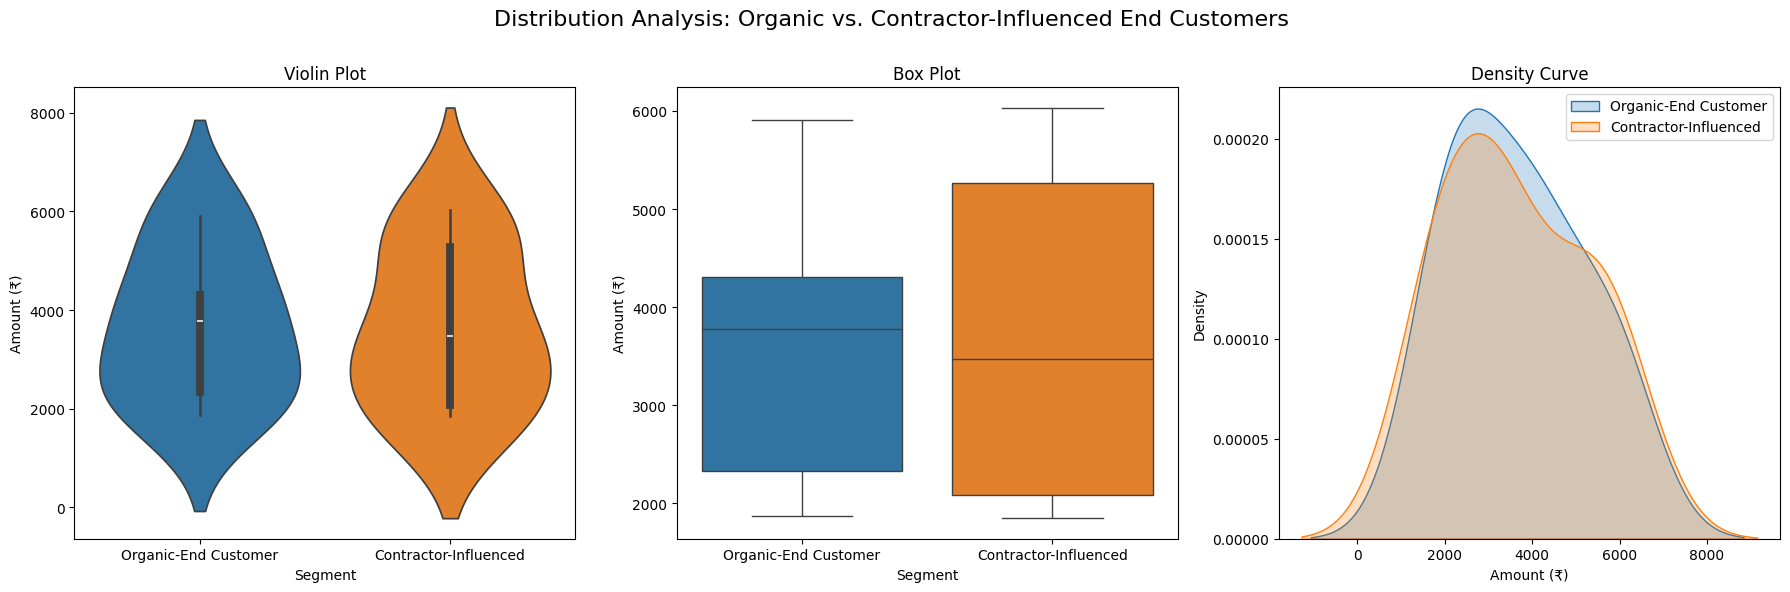

In [4]:
# Assuming df is already created from the previous data preparation step
plt.figure(figsize=(18, 6))

# Subplot 1: Violin Plot
plt.subplot(1, 3, 1)
sns.violinplot(data=df)
plt.title('Violin Plot')
plt.xlabel('Segment')
plt.ylabel('Amount (₹)')

# Subplot 2: Box Plot
plt.subplot(1, 3, 2)
sns.boxplot(data=df)
plt.title('Box Plot')
plt.xlabel('Segment')
plt.ylabel('Amount (₹)')

# Subplot 3: Density Curve
plt.subplot(1, 3, 3)
for column in df.columns:
    sns.kdeplot(data=df[column], label=column, shade=True)
plt.title('Density Curve')
plt.xlabel('Amount (₹)')
plt.ylabel('Density')
plt.legend()

# Adjust layout and show
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.suptitle('Distribution Analysis: Organic vs. Contractor-Influenced End Customers \n', fontsize=16)
plt.show();